In [1]:
# 1-1. 필수 라이브러리 import
import torch
import torchvision
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights
from torchvision.transforms import functional as F
from torchvision.utils import draw_bounding_boxes
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# 한글 폰트 설정 (matplotlib 한글 깨짐 방지)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print("="*50)
print("="*50)
print(f"PyTorch 버전: {torch.__version__}")
print(f"TorchVision 버전: {torchvision.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

PyTorch 버전: 2.10.0+cu128
TorchVision 버전: 0.25.0+cu128
CUDA 사용 가능: True
사용 디바이스: cuda


In [15]:
weights = SSD300_VGG16_Weights.DEFAULT
model = ssd300_vgg16(weights = weights)
model.eval()
model = model.to(device)

print(f"model type : {type(model).__name__}")
class_names = weights.meta["categories"]
print(f"total possible class types : {len(class_names)} ")


def download_image(url):
  response = requests.get(url)
  img = Image.open(BytesIO(response.content)).convert("RGB")
  return img


def preprocess_image(img) :
  pre = weights.transforms()
  img_tensor = pre(img).to(device)
  original = img.copy()
  return [img_tensor], original

test_image_urls = [
    "https://images.unsplash.com/photo-1568605114967-8130f3a36994?w=800",  # people
    "https://images.unsplash.com/photo-1449965408869-eaa3f722e40d?w=800",  # street
    "https://images.unsplash.com/photo-1544568100-847a948585b9?w=800",   # puppy
]

img = download_image(test_image_urls[1])

model type : SSD
total possible class types : 91 


In [16]:
def detect_objects(model,img,thr) :
  with torch.no_grad():
    logits = model(img)

  pred = logits[0] # predict first image
  filtered_pred_total={}
  for th in thr :
    keep_indices = (pred['scores'] > th) # only left prediciton over threshold

    filtered_pred = {
        'boxes' : pred['boxes'][keep_indices],
        'labels' : pred['labels'][keep_indices],
        'scores' : pred['scores'][keep_indices]
    }
    filtered_pred_total[th] = filtered_pred
    num_detections = len(filtered_pred['boxes'])
    print(f"filtered detection : {num_detections}")

    if num_detections > 0 :
      for i in range(num_detections):
        label_id = filtered_pred['labels'][i].item()
        score = filtered_pred['scores'][i].item()
        class_name = class_names[label_id]
        print(f'{i+1}. {class_name:15s} | confidence : {score:.2%}')
      print("_"*60)

  return filtered_pred_total




test 1/3: https://images.unsplash.com/photo-1568605114967-8130f3a36994?w=800
filtered detection : 1
1. car             | confidence : 35.83%
____________________________________________________________
filtered detection : 0
filtered detection : 0

test 2/3: https://images.unsplash.com/photo-1449965408869-eaa3f722e40d?w=800
filtered detection : 3
1. person          | confidence : 83.65%
2. dog             | confidence : 28.20%
3. tv              | confidence : 26.69%
____________________________________________________________
filtered detection : 1
1. person          | confidence : 83.65%
____________________________________________________________
filtered detection : 1
1. person          | confidence : 83.65%
____________________________________________________________

test 3/3: https://images.unsplash.com/photo-1544568100-847a948585b9?w=800
filtered detection : 1
1. dog             | confidence : 85.64%
____________________________________________________________
filtered detecti

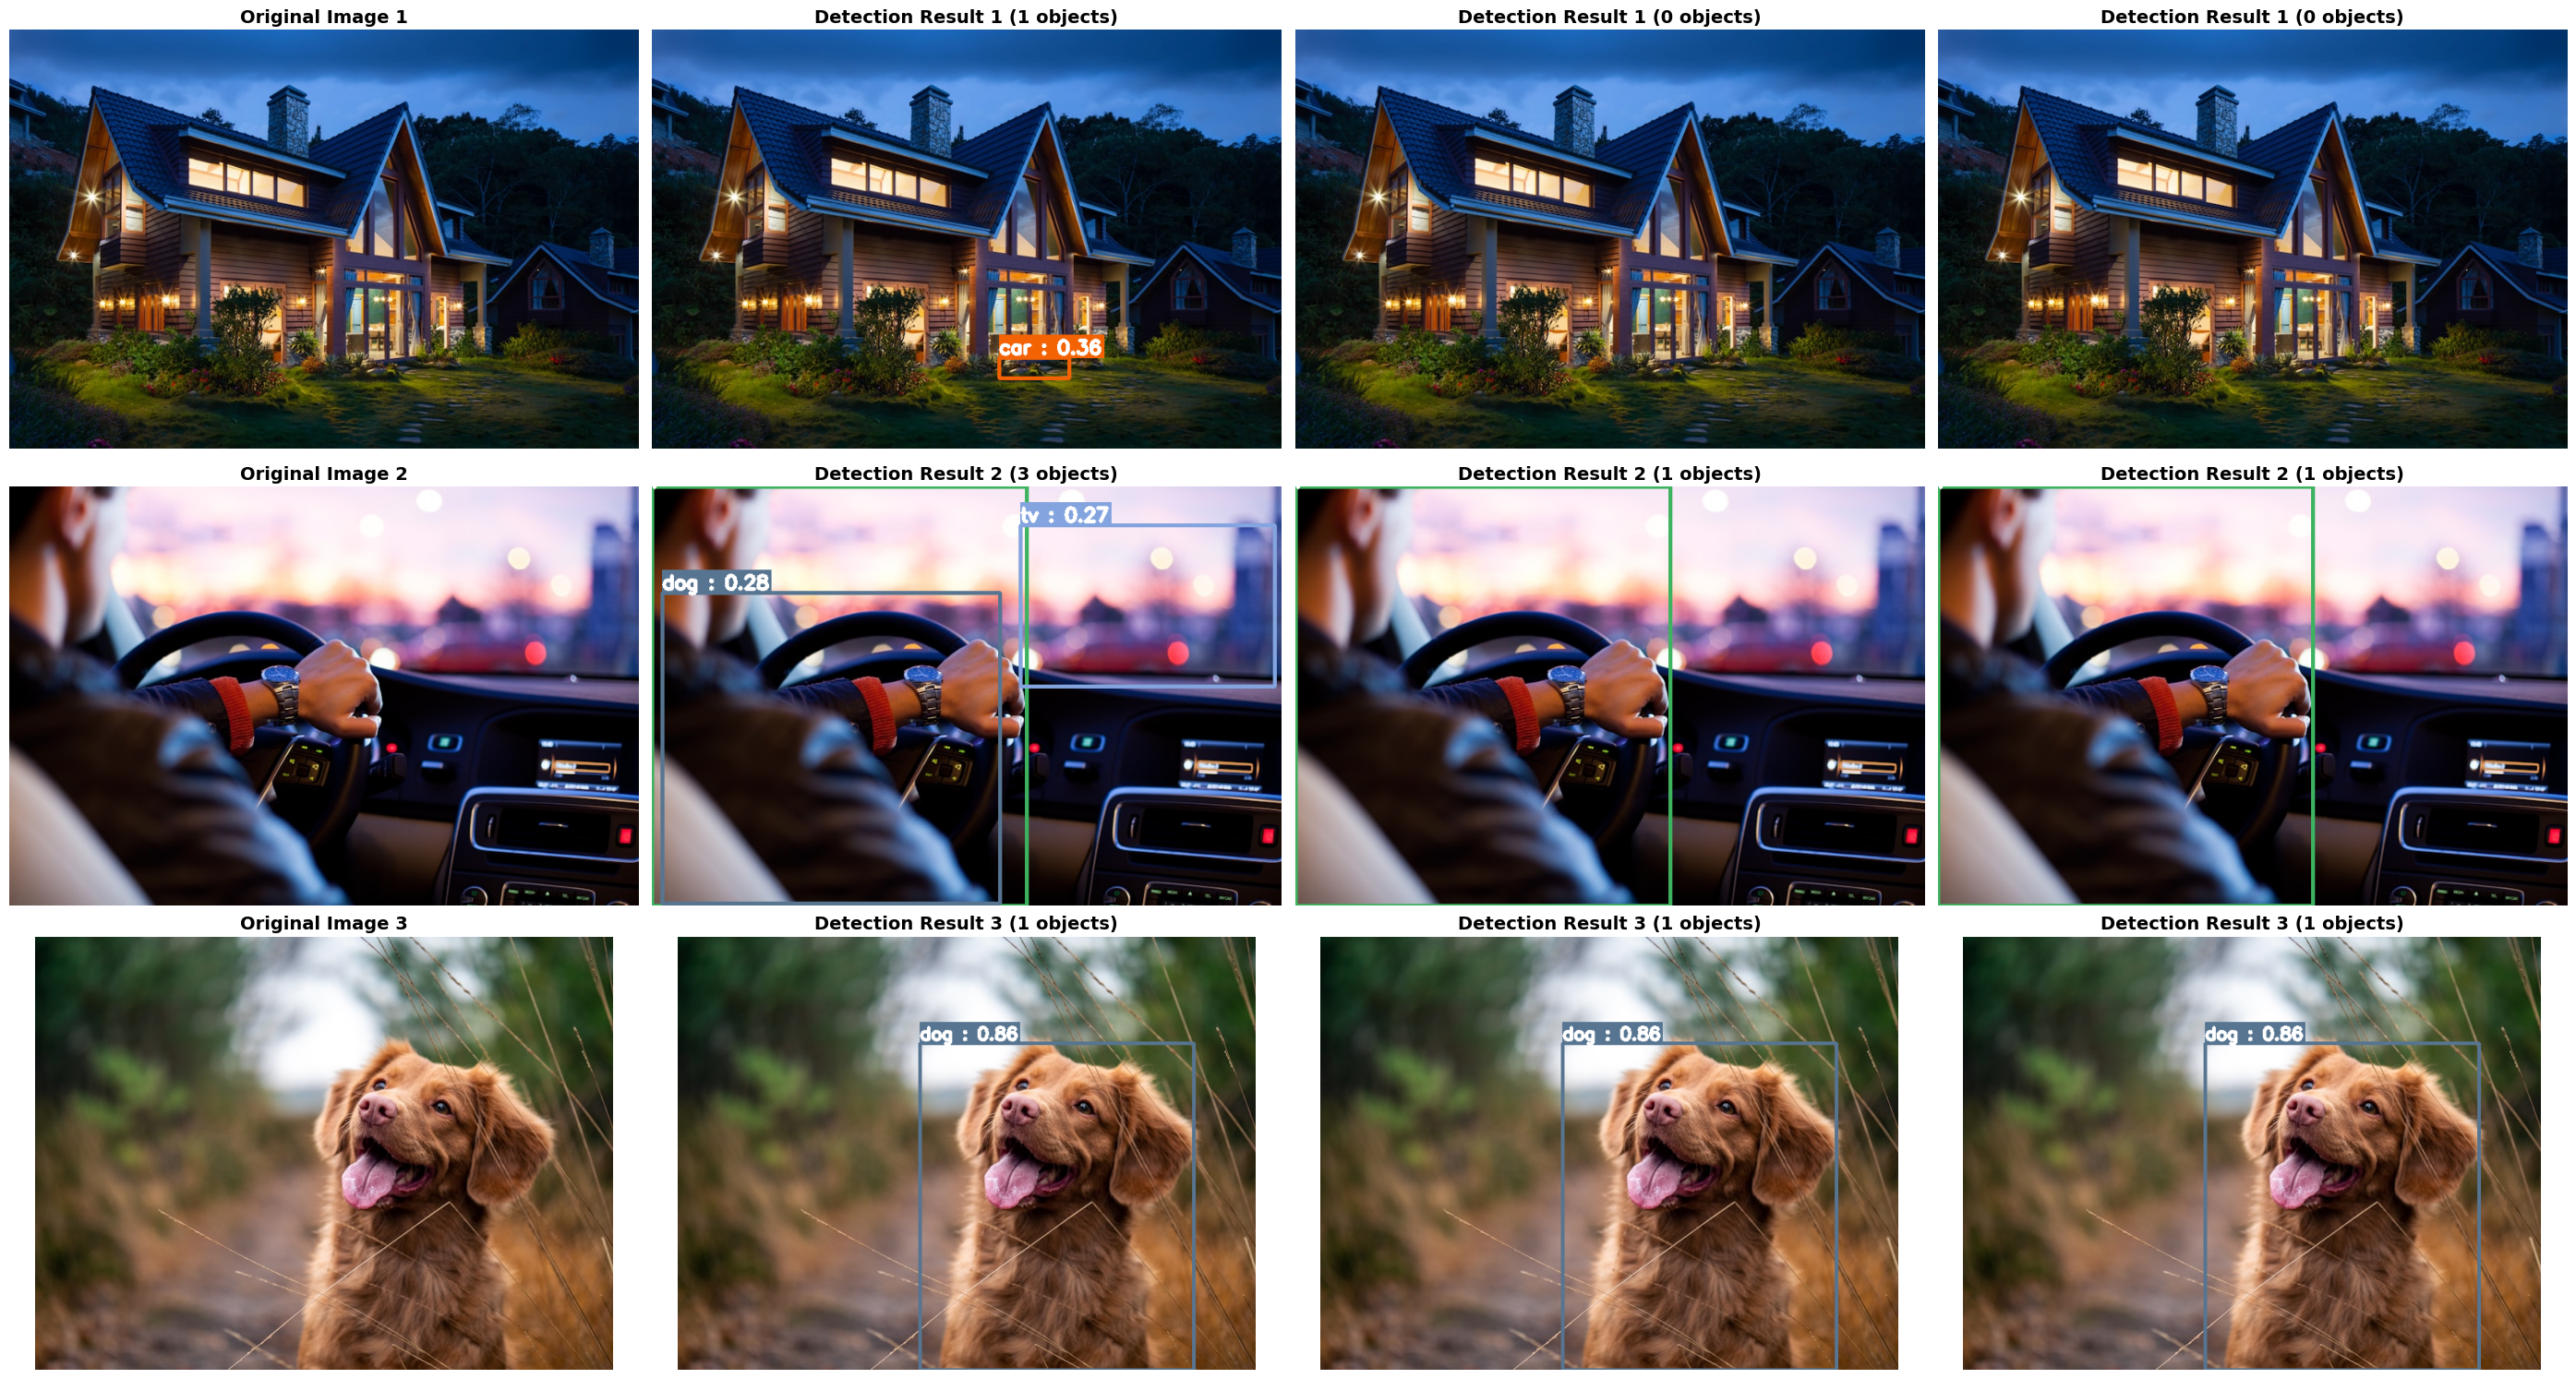

In [20]:
def visualize(img,predictions,class_names,font_scale=0.8,thickness=3):
  img_np = np.array(img)
  img_cv = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
  boxes = predictions['boxes'].cpu().numpy()
  labels = predictions['labels'].cpu().numpy()
  scores = predictions['scores'].cpu().numpy()

  np.random.seed(42)
  colors = np.random.randint(0, 255, size=(len(class_names), 3), dtype=np.uint8)

  for box, label, score in zip(boxes,labels,scores):
    x1,y1,x2,y2 = box.astype(int)

    class_name = class_names[label]
    color = colors[label].tolist()

    cv2.rectangle(img_cv, (x1,y1),(x2,y2),color, thickness)
    text = f"{class_name} : {score:.2f}"
    # textbackground
    (text_w,text_h),_ = cv2.getTextSize(
        text,cv2.FONT_HERSHEY_SIMPLEX, font_scale,thickness
    )

    cv2.rectangle(img_cv,(x1,y1-text_h-10), (x1 + text_w,y1), color, -1)
    cv2.putText(img_cv,text,(x1,y1-5),cv2.FONT_HERSHEY_SIMPLEX,font_scale,(255,255,255),thickness)

  img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
  return img_rgb

thr = [0.2, 0.5,0.8]
num_images = len(test_image_urls)
fig, axes = plt.subplots(num_images,len(thr)+1, figsize =(7*(len(thr)+1),5 *num_images))

if num_images ==1 :
  axes = axes.reshape(1,-1)

for idx, url in enumerate(test_image_urls):
      print(f"\n{'='*60}")
      print(f"test {idx+1}/{num_images}: {url}")
      print('='*60)

      image = download_image(url)
      if image is None :
        continue
      image_tensor,original = preprocess_image(image)
      axes[idx, 0].imshow(original)
      axes[idx, 0].set_title(f"Original Image {idx+1}", fontsize=14, fontweight='bold')
      axes[idx, 0].axis('off')
      predictions = detect_objects(model, image_tensor,thr)
      result = []
      for i,th in enumerate(thr) :
        result.append(visualize(original,predictions[th],class_names))


        axes[idx, i+1].imshow(result[i])
        axes[idx, i+1].set_title(f"Detection Result {idx+1} ({len(predictions[th]['boxes'])} objects)",
                              fontsize=14, fontweight='bold')
        axes[idx, i+1].axis('off')

plt.tight_layout()
plt.show()



